## Premier entraînement PPO

**Paramètres**

PRETRAINED_WEIGHTS = '../saved-models/PPO-pretrained.h5'
SAVE_PATH = '../saved-models/ppo-v2'

N_ITERATIONS = 500
N_GAMES = 64
N_EPOCHS = 4
MINIBATCH_SIZE = 64
LEARNING_RATE = 1e-4
CLIP_EPSILON = 0.1
VALUE_COEF = 0.5
ENTROPY_COEF = 0.005
GAMMA = 0.99
LAM = 0.95
SAVE_EVERY = 10

# Fréquence de mise à jour des graphiques (toutes les N itérations)
PLOT_EVERY = 1

#Fréquence de réalisation d'un test d'efficience du réseau
EFFICIENCY_EVERY = 20
EFFICIENCY_NB_GAMES = 100


p1 = CNNPlayer_v2()
p1.load_weights(PRETRAINED_WEIGHTS)
p2 = CNNPlayer_v2()

p2_alt1 = LookAheadHeuristicPlayer(max_depth=2, heuristic_function="heuristic_defensive")

trainer = PPOTrainer(
    player1=p1,
    player2=p2,
    n_games=N_GAMES,
    n_epochs=N_EPOCHS,
    minibatch_size=MINIBATCH_SIZE,
    learning_rate=LEARNING_RATE,
    clip_epsilon=CLIP_EPSILON,
    value_coef=VALUE_COEF,
    entropy_coef=ENTROPY_COEF,
    gamma=GAMMA,
    lam=LAM,
    alternative_players=[p2_alt1],
    alternative_players_ratio=[10]
)

print("Modèle et trainer initialisés.")

**Explications**



Problème principal : régression après le pic
Les deux courbes d'efficiency racontent la même histoire :

Métrique	Pic (~iter 150-180)	Actuellement (~iter 320)
vs Heuristique	0.95-0.96	~0.84
vs LookAhead2	0.40-0.41	~0.27
Le modèle a régressé significativement sur les deux benchmarks depuis ~170 itérations.

Causes probables
Entropie trop basse (0.6) : la politique est devenue trop déterministe, plus d'exploration. Le modèle est probablement bloqué dans un optimum local étroit
Overfitting au self-play : en s'adaptant uniquement à lui-même, le modèle perd en généralisation contre des adversaires extérieurs
Policy loss qui remonte vers 0 : le signal d'apprentissage s'affaiblit
Ce qu'il faut conserver
Les poids autour de l'itération 150-180 — c'est là que le modèle était au meilleur niveau réel. C'est le checkpoint à garder.

Pour la suite
Si tu continues l'entraînement, plusieurs pistes :

Repartir du checkpoint ~iter 150 avec un coefficient d'entropie plus élevé pour forcer plus d'exploration
Ajouter un adversaire fixe (frozen policy) dans le self-play pour éviter la dérive cyclique
Réduire le learning rate — la policy loss oscille beaucoup, signe d'instabilité

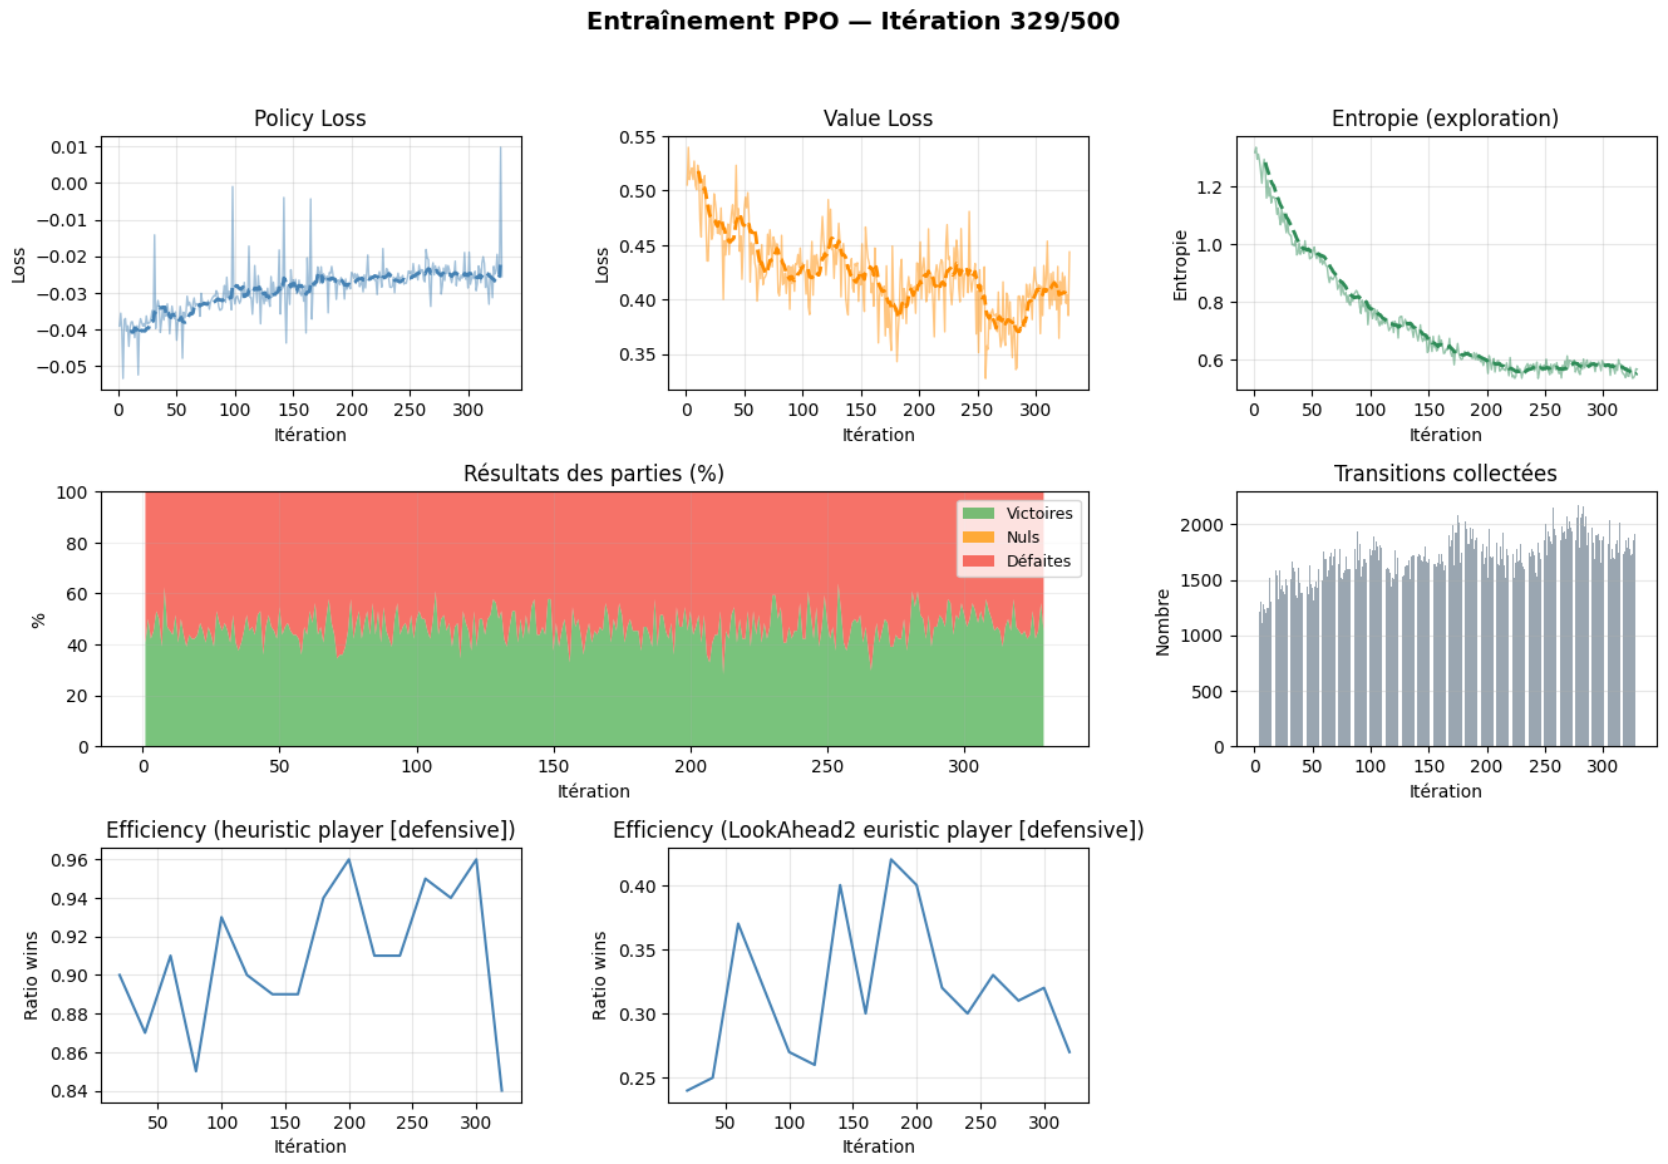



Modèle PPO-Model1.h5